## 🎯 05 — Support Vector Machine (SVM)

**What it does:** Finds the best hyperplane that maximally 
separates classes in high-dimensional space.  
**Best used when:** High dimensional data, clear margin of separation.  
**Dataset:** Wine Recognition (built-in sklearn)  
**Algorithm type:** Supervised → Multiclass Classification  
**Key concept:** Maximizing the margin between classes  
**⚠️ Feature scaling required!**  
**Model saved as:** `models/svm.pkl`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report)
import pickle
import os

In [2]:
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

print("Shape:", df.shape)
print("\nClasses:", wine.target_names)
print("\nClass distribution:")
print(df['target'].value_counts().sort_index())
df.head()

Shape: (178, 14)

Classes: ['class_0' 'class_1' 'class_2']

Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


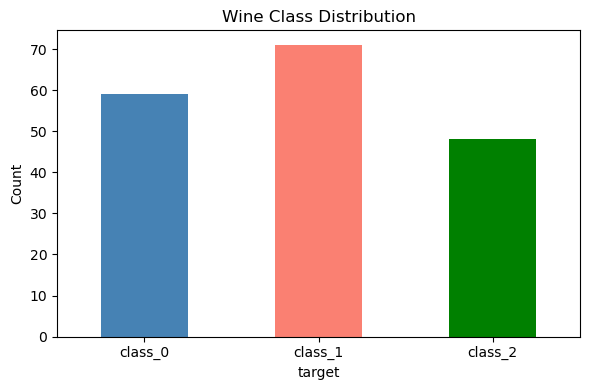

In [4]:
# Class distribution
plt.figure(figsize=(6,4))
df['target'].value_counts().sort_index().plot(
    kind='bar', color=['steelblue','salmon','green'])
plt.xticks([0,1,2], wine.target_names, rotation=0)
plt.title('Wine Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

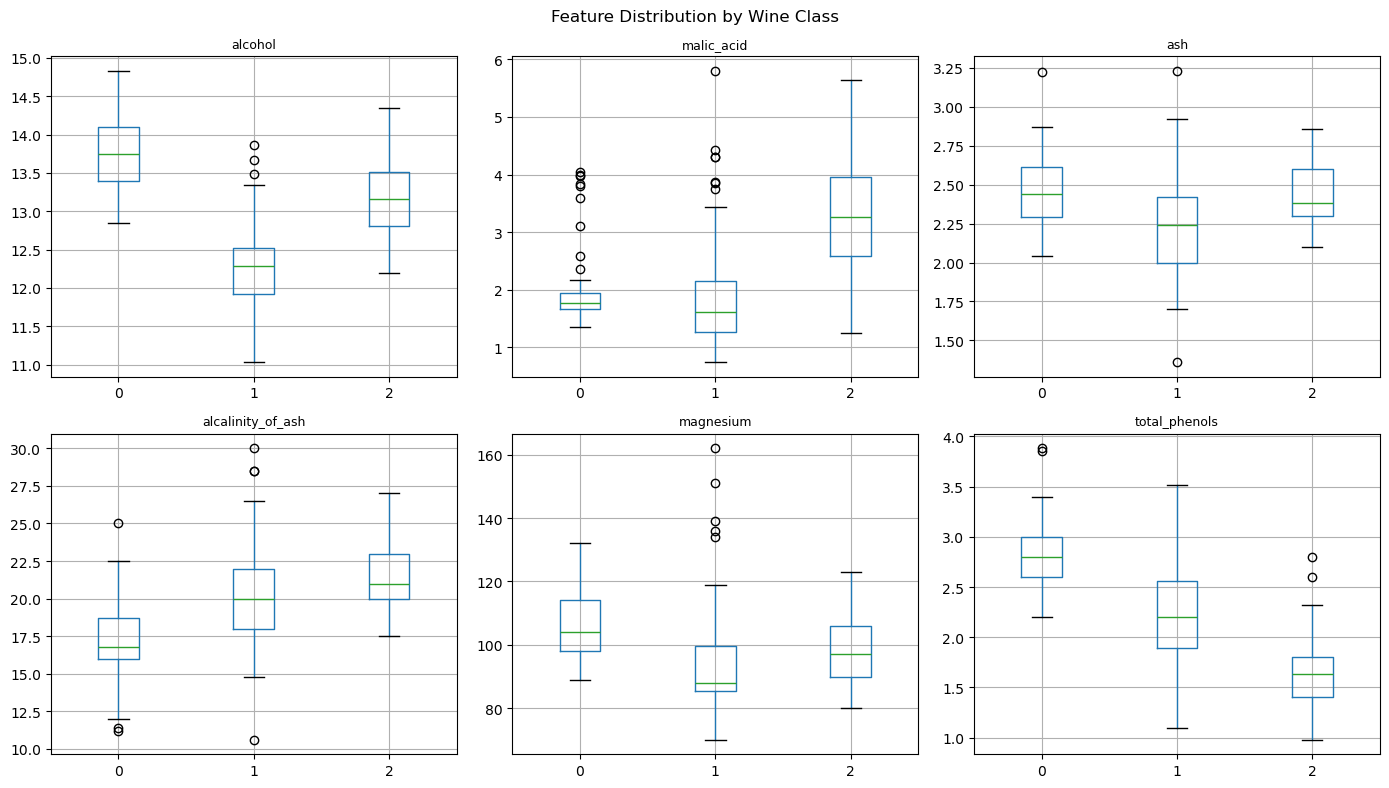

In [5]:
# Feature boxplots — top 6 features
fig, axes = plt.subplots(2, 3, figsize=(14,8))
top_features = wine.feature_names[:6]
for idx, feature in enumerate(top_features):
    ax = axes[idx//3][idx%3]
    df.boxplot(column=feature, by='target', ax=ax)
    ax.set_title(feature, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Feature Distribution by Wine Class')
plt.tight_layout()
plt.show()

In [6]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale — critical for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 142
Testing samples: 36


In [7]:
# Train SVM with RBF kernel
model = SVC(kernel='rbf', C=1.0,
            gamma='scale', random_state=42,
            probability=True)
model.fit(X_train_scaled, y_train)
print("Model trained successfully ✅")
print(f"Kernel: {model.kernel}")
print(f"Support vectors per class: {model.n_support_}")

Model trained successfully ✅
Kernel: rbf
Support vectors per class: [15 30 18]


In [8]:
y_pred = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=wine.target_names))

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



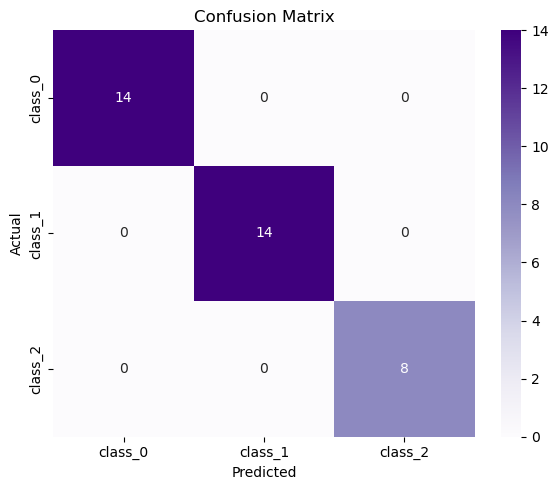

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=wine.target_names,
            yticklabels=wine.target_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

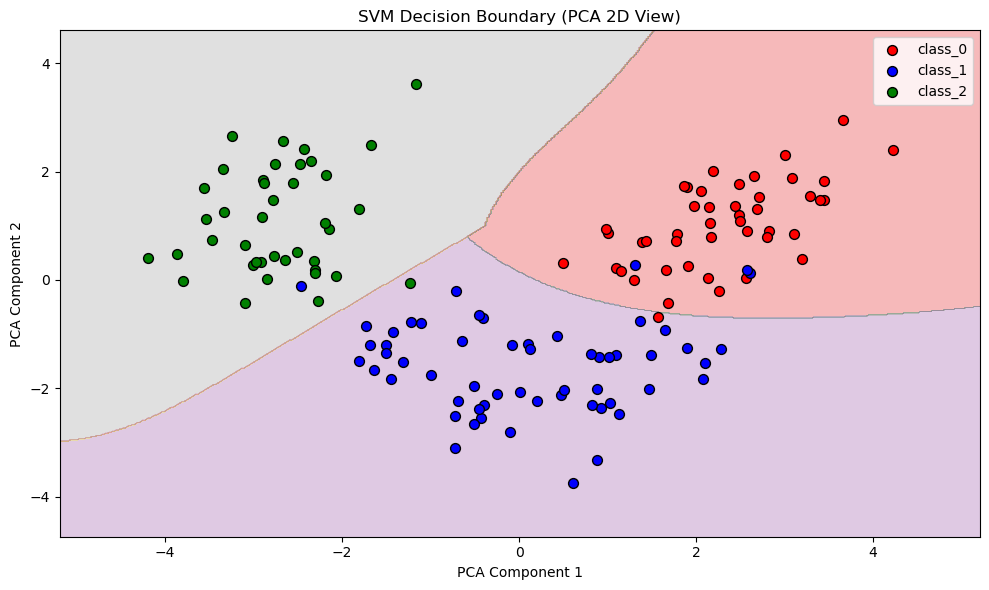

In [10]:
# Visualize SVM decision boundary using 2 features (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d  = pca.transform(X_test_scaled)

svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_2d.fit(X_train_2d, y_train)

# Plot decision boundary
x_min, x_max = X_train_2d[:,0].min()-1, X_train_2d[:,0].max()+1
y_min, y_max = X_train_2d[:,1].min()-1, X_train_2d[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')
colors = ['red','blue','green']
for i, color in enumerate(colors):
    mask = y_train == i
    plt.scatter(X_train_2d[mask,0], X_train_2d[mask,1],
                c=color, label=wine.target_names[i],
                edgecolors='black', s=50)
plt.title('SVM Decision Boundary (PCA 2D View)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
with open('svm.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved ✅")
print("Scaler saved ✅")

Model saved ✅
Scaler saved ✅


## ✅ Summary

| Metric | Value |
|--------|-------|
| Accuracy | ~100% |
| Kernel | RBF |
| C parameter | 1.0 |
| Training Samples | 142 |
| Testing Samples | 36 |

**Key concepts learned:**
- SVM finds a hyperplane maximizing margin between classes
- RBF kernel handles non-linear boundaries
- C parameter controls tradeoff: small C = wider margin,
  large C = fewer misclassifications
- Always scale before SVM — unscaled features break the margin
- Decision boundary visualization needs PCA to reduce to 2D

**Scaling needed:** ✅ Yes (same as Logistic Regression)
**Next model → KNN (distance-based, also needs scaling!)**